In [1]:
import os
os.getcwd()


'c:\\Users\\quimb\\OneDrive\\Documents\\Pruebas\\Mercado Libre\\mlops-housing-api\\notebooks'

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Asegurar acceso al src
sys.path.append(os.path.abspath(".."))

from src.data import load_data, split_data

sns.set(style="whitegrid")

In [3]:
df = load_data()
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# 📘 Glosario de variables – Boston Housing

## 🎯 Variable objetivo

- **MEDV**  
  Valor mediano de las viviendas ocupadas por sus dueños  
  Unidad: miles de dólares  
  Ej: 25 = $25,000  

---

## 🏙️ Variables explicativas

### 🧭 Ubicación y accesibilidad

- **DIS**  
  Distancia ponderada a centros de empleo  
  Más alto = más lejos del trabajo  

- **RAD**  
  Índice de accesibilidad a autopistas  
  Más alto = mejor acceso vial  

---

### 🏭 Entorno y contaminación

- **NOX**  
  Concentración de óxidos de nitrógeno  
  Proxy de contaminación del aire  

- **INDUS**  
  Proporción de áreas industriales  
  Más alto = zona más industrial  

---

### 👮 Factores urbanos / sociales

- **CRIM**  
  Tasa de criminalidad per cápita  
  Más alto = más inseguridad  

- **LSTAT**  
  % de población de bajo estatus socioeconómico  
  Alta correlación negativa con el precio  

---

### 🏠 Características de las viviendas

- **RM**  
  Número promedio de habitaciones por vivienda  
  Alta correlación positiva con el precio  

- **AGE**  
  % de viviendas construidas antes de 1940  
  Más alto = viviendas más antiguas  

---

### 🏫 Educación

- **PTRATIO**  
  Ratio alumno/profesor  
  Más alto = menor calidad educativa (proxy)  

---

### 💰 Impuestos y economía

- **TAX**  
  Tasa de impuestos a la propiedad  
  Más alto = mayor carga fiscal  

---

### 🧑‍🤝‍🧑 Factores socioeconómicos

- **ZN**  
  Proporción de terrenos residenciales de baja densidad  
  Más alto = zonas más exclusivas  

- **B**  
  Variable construida relacionada con composición racial  
  ⚠️ Puede implicar sesgos en el modelo  

---

### 🚧 Variable dummy

- **CHAS**  
  Indica si la vivienda está cerca del río Charles  
  1 = sí, 0 = no  

---

## ⚠️ Consideraciones éticas

El dataset incluye variables como **B** y **LSTAT**, que pueden estar asociadas a factores socioeconómicos y raciales.  
Esto implica que el modelo puede aprender patrones que reflejan sesgos históricos, por lo que su uso en producción real debe evaluarse cuidadosamente.

In [5]:
print(f"Shape: {df.shape}")
df.info()

Shape: (506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [6]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


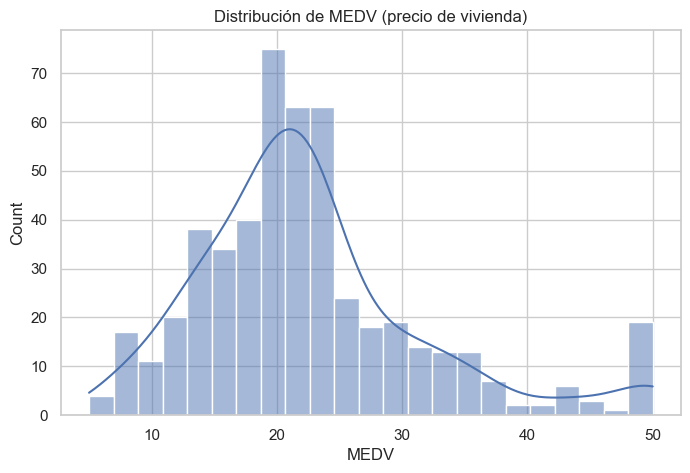

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], kde=True)
plt.title("Distribución de MEDV (precio de vivienda)")
plt.show()

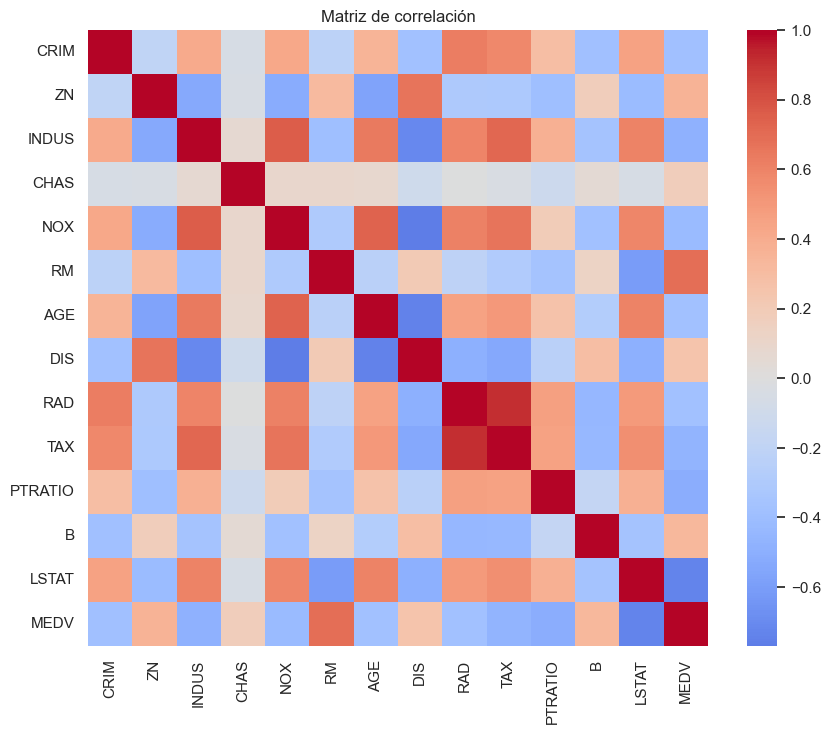

In [9]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [10]:
corr["MEDV"].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

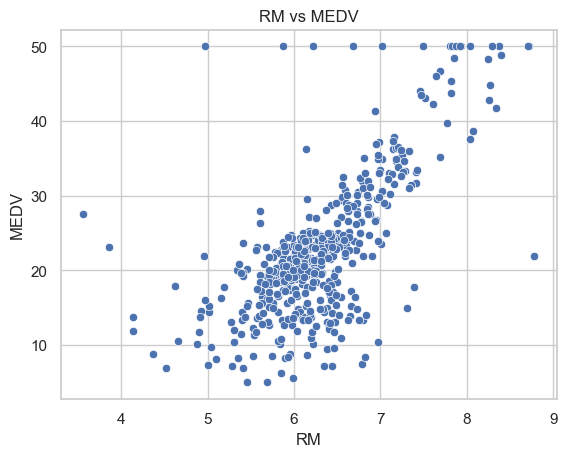

In [11]:
sns.scatterplot(x=df["RM"], y=df["MEDV"])
plt.title("RM vs MEDV")
plt.show()

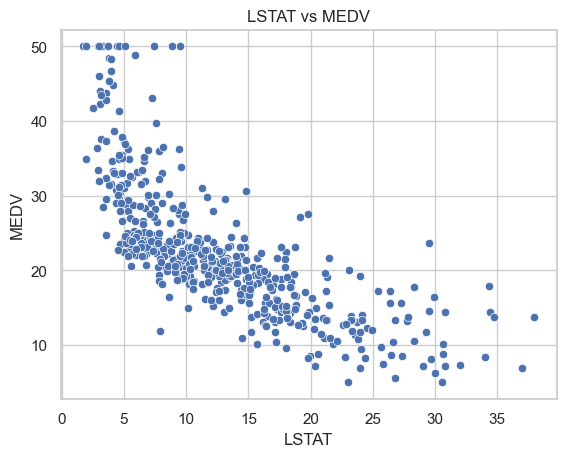

In [12]:
sns.scatterplot(x=df["LSTAT"], y=df["MEDV"])
plt.title("LSTAT vs MEDV")
plt.show()

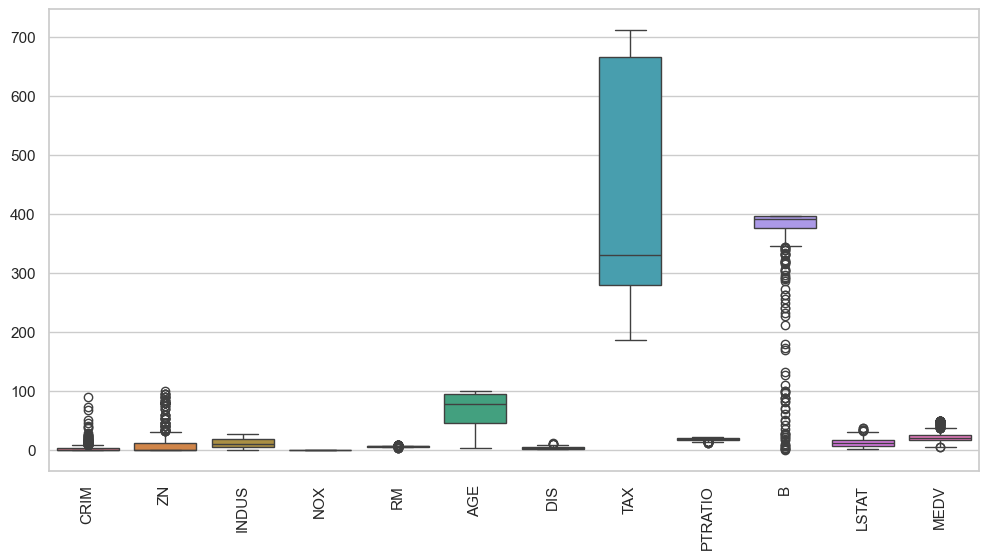

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

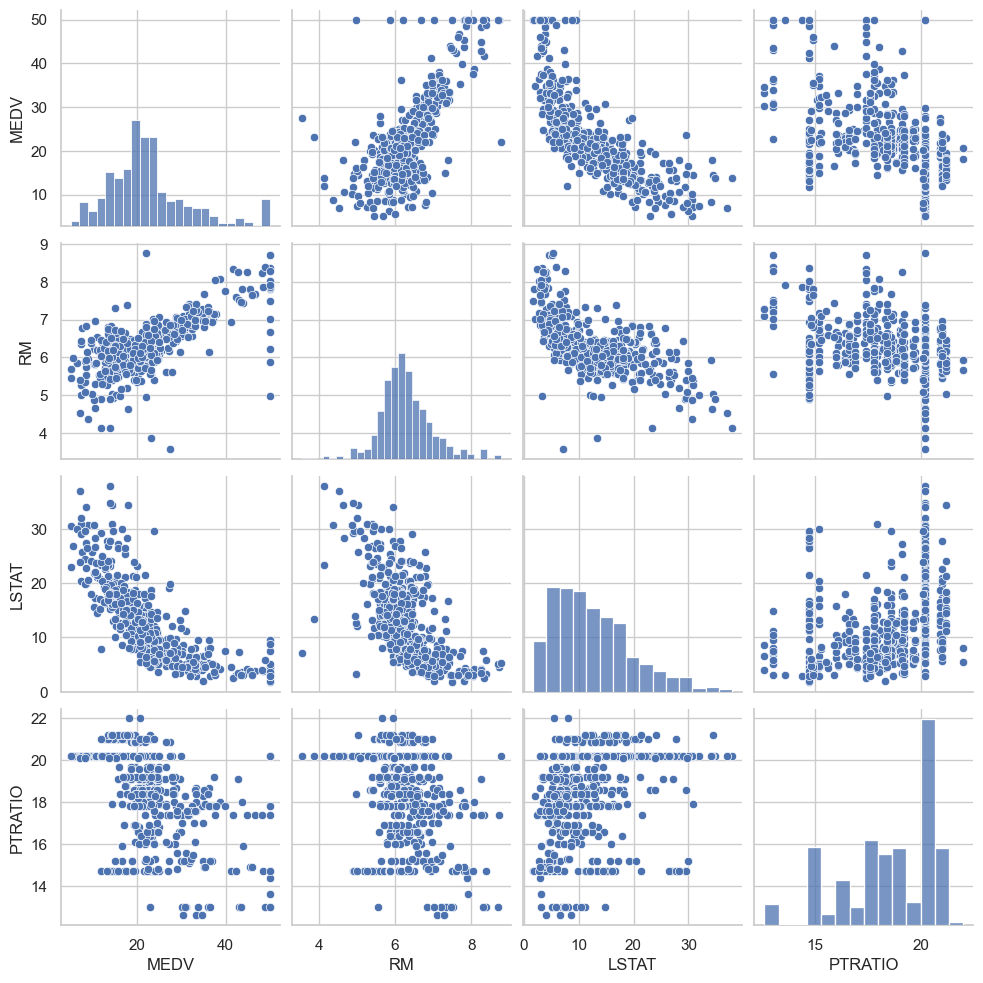

In [14]:
sns.pairplot(df[["MEDV", "RM", "LSTAT", "PTRATIO"]])

# 🧠 Conclusión del Análisis Exploratorio

A partir del análisis exploratorio del dataset Boston Housing se identificaron varios aspectos clave que guían el diseño del modelo de Machine Learning.

## 📊 Hallazgos principales

- El dataset cuenta con un número limitado de observaciones (~500 registros), lo cual implica un riesgo de sobreajuste y favorece el uso de modelos robustos y bien regularizados.

- La variable objetivo (**MEDV**) presenta una distribución aproximadamente normal, pero con un límite superior (censura en 50), lo que puede afectar la capacidad del modelo para predecir correctamente valores altos.

- Se identificaron relaciones relevantes entre variables:
  - **RM** (número de habitaciones) muestra una fuerte correlación positiva con el precio.
  - **LSTAT** (% de población de bajo estatus socioeconómico) presenta una fuerte correlación negativa.
  - Otras variables como **PTRATIO** también muestran influencia moderada.

- No se evidencian valores nulos, lo que simplifica el pipeline de procesamiento.

- Existen outliers en varias variables (por ejemplo, CRIM, B, TAX), sin embargo, estos pueden representar información válida del fenómeno y no necesariamente deben ser eliminados en una primera iteración.

- Las variables presentan diferentes escalas, lo cual hace necesario aplicar técnicas de normalización dentro del pipeline.

## ⚙️ Implicaciones para el modelamiento

- Las relaciones observadas sugieren que el problema no es completamente lineal, por lo que modelos basados en árboles (como Random Forest o Gradient Boosting) son adecuados.

- Se recomienda utilizar un pipeline de preprocessing que incluya imputación y escalado de variables para garantizar consistencia entre entrenamiento e inferencia.

- Dado el tamaño del dataset, es importante evitar modelos excesivamente complejos y considerar técnicas de validación adecuadas.

- Los outliers deben ser manejados implícitamente mediante modelos robustos en lugar de ser eliminados inicialmente.

- La censura en la variable objetivo debe ser considerada al interpretar las métricas del modelo.

## ⚠️ Consideraciones adicionales

- Algunas variables del dataset están relacionadas con factores socioeconómicos y potencialmente sensibles, lo cual implica que el modelo puede reflejar sesgos históricos. Esto debe ser tenido en cuenta en un contexto real de producción.

---

## 🚀 Conclusión

El análisis exploratorio permitió entender la estructura del problema, identificar variables clave y definir una estrategia de modelamiento adecuada. Con base en estos hallazgos, se opta por un enfoque basado en modelos no lineales con un pipeline de preprocessing robusto, priorizando interpretabilidad, estabilidad y capacidad de generalización.